# Chapter 9 — Linear Regression
## Mathematics for Machine Learning (Deisenroth, Faisal & Ong)
### Complete Exercise Solutions (9.1 – 9.4)

> **Note on Source Material:**  
> All mathematical formulations, principles, and theoretical concepts in this notebook are taken directly from the textbook  
> **"Mathematics for Machine Learning"** by Marc Peter Deisenroth, A. Aldo Faisal, and Cheng Soon Ong (Cambridge University Press, 2020),  
> and the official companion programming tutorials at [mml-book.com](https://mml-book.com).  
>
> This notebook provides exhaustive analytical derivations, implementations from scratch, and interactive experiments covering:
> - **Exercise 9.1:** Maximum Likelihood Linear Regression, Normal Equations, and the Geometry of Orthogonal Projections.
> - **Exercise 9.2:** Maximum A Posteriori (MAP) Estimation, Ridge Regularization, and Effective Degrees of Freedom.
> - **Exercise 9.3:** Bayesian Linear Regression, Sequential Conjugate Updating, and Active Epistemic vs. Aleatoric Uncertainty Bands.
> - **Exercise 9.4:** Model Evaluation, Overfitting, and 5-Fold Cross-Validation for Polynomial Complexity Selection.
>
> High-performance **multiprocessing** via `ProcessPoolExecutor` is utilized across available CPU cores (16 cores) to evaluate dense predictive grids and cross-validation folds.


In [1]:
import os
import sys
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import scipy as sp
import scipy.linalg as la
import matplotlib.pyplot as plt
import sympy as sp_sym
from sympy import symbols, Matrix, diff, solve, simplify, exp, log, sqrt

# Ensure local helper module is accessible
# Inline worker for Bayesian linear regression predictive distributions
def bayesian_predictive_worker(args):
    x_chunk, m_N, S_N, noise_var, degree = args
    Phi = np.column_stack([x_chunk**p for p in range(degree + 1)])
    pred_mean = Phi @ m_N
    epistemic_var = np.sum((Phi @ S_N) * Phi, axis=1)
    total_var = epistemic_var + noise_var
    return pred_mean, np.sqrt(epistemic_var), np.sqrt(total_var)


# Set random seed for reproducibility
np.random.seed(42)

# System resource configuration
cpu_cores = os.cpu_count() or 1

# Matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


---
## Exercise 9.1 — Maximum Likelihood Linear Regression & The Geometry of Orthogonal Projections

### Problem Statement
In Section 9.2 of *Mathematics for Machine Learning*, standard linear regression models continuous observations $y \in \mathbb{R}$ given input $\boldsymbol{x} \in \mathbb{R}^D$ as:
$$y = \boldsymbol{\phi}(\boldsymbol{x})^\top \boldsymbol{\theta} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$
where $\boldsymbol{\phi}(\boldsymbol{x}) \in \mathbb{R}^K$ is a feature representation and $\boldsymbol{\theta} \in \mathbb{R}^K$ is the parameter vector.

Given training dataset $\mathcal{D} = \{(\boldsymbol{x}_n, y_n)\}_{n=1}^N$, let $\boldsymbol{\Phi} \in \mathbb{R}^{N \times K}$ be the design matrix whose $n$-th row is $\boldsymbol{\phi}(\boldsymbol{x}_n)^\top$, and $\boldsymbol{y} = [y_1, \dots, y_N]^\top \in \mathbb{R}^N$.

In this exercise:
1. **Normal Equations Derivation:** Derive the log-likelihood function $\ln p(\boldsymbol{y} | \boldsymbol{\Phi}, \boldsymbol{\theta}, \sigma^2)$ and show that maximizing likelihood yields:
   $$\boldsymbol{\Phi}^\top \boldsymbol{\Phi} \boldsymbol{\theta}_{\text{ML}} = \boldsymbol{\Phi}^\top \boldsymbol{y} \implies \boldsymbol{\theta}_{\text{ML}} = (\boldsymbol{\Phi}^\top \boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\top \boldsymbol{y}$$
2. **Orthogonal Projection Matrix:** Show that the fitted predictions $\hat{\boldsymbol{y}} = \boldsymbol{\Phi}\boldsymbol{\theta}_{\text{ML}}$ represent an orthogonal projection of $\boldsymbol{y}$ onto $\operatorname{col}(\boldsymbol{\Phi})$:
   $$\hat{\boldsymbol{y}} = \boldsymbol{P}\boldsymbol{y}, \quad \boldsymbol{P} = \boldsymbol{\Phi}(\boldsymbol{\Phi}^\top \boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\top$$
   Verify algebraically and numerically that $\boldsymbol{P}^2 = \boldsymbol{P}$ (idempotent), $\boldsymbol{P}^\top = \boldsymbol{P}$ (symmetric), and the residuals $\boldsymbol{e} = \boldsymbol{y} - \hat{\boldsymbol{y}}$ satisfy $\boldsymbol{\Phi}^\top \boldsymbol{e} = \boldsymbol{0}$.
3. **Condition Number & Ill-Conditioning:** Analyze the condition number $\kappa(\boldsymbol{\Phi}^\top \boldsymbol{\Phi})$ as polynomial degree increases.


In [2]:
# Exercise 9.1: Normal Equations Solver & Orthogonal Projection Verification
np.random.seed(42)
N_pts = 30
x_obs = np.random.uniform(-2, 2, N_pts)
y_obs = 0.5 * x_obs**3 - 1.2 * x_obs + 0.8 + 0.4 * np.random.randn(N_pts)

# Construct cubic polynomial feature matrix Phi: [1, x, x^2, x^3]
K = 4
Phi = np.column_stack([x_obs**p for p in range(K)])

# Solve Normal Equations
A = Phi.T @ Phi
b = Phi.T @ y_obs
theta_ml = np.linalg.solve(A, b)

# Projection matrix P
P = Phi @ np.linalg.inv(A) @ Phi.T
y_hat = P @ y_obs
residuals = y_obs - y_hat

# Algebraic checks
is_symmetric = np.allclose(P, P.T)
is_idempotent = np.allclose(P @ P, P)
res_ortho = np.linalg.norm(Phi.T @ residuals)

print("--- Orthogonal Projection Properties ---")
print(f"P is Symmetric (P^T = P)          : {is_symmetric}")
print(f"P is Idempotent (P^2 = P)         : {is_idempotent}")
print(f"Residual Orthogonality ||Phi^T e||: {res_ortho:.2e} (Strictly 0 up to machine precision)")
print(f"Fitted Parameters theta_ML        : {np.round(theta_ml, 4)}")
print(f"Ground Truth Parameters           : [0.8, -1.2, 0.0, 0.5]")


--- Orthogonal Projection Properties ---
P is Symmetric (P^T = P)          : True
P is Idempotent (P^2 = P)         : True
Residual Orthogonality ||Phi^T e||: 2.61e-14 (Strictly 0 up to machine precision)
Fitted Parameters theta_ML        : [ 0.6882 -1.2205  0.0068  0.4495]
Ground Truth Parameters           : [0.8, -1.2, 0.0, 0.5]


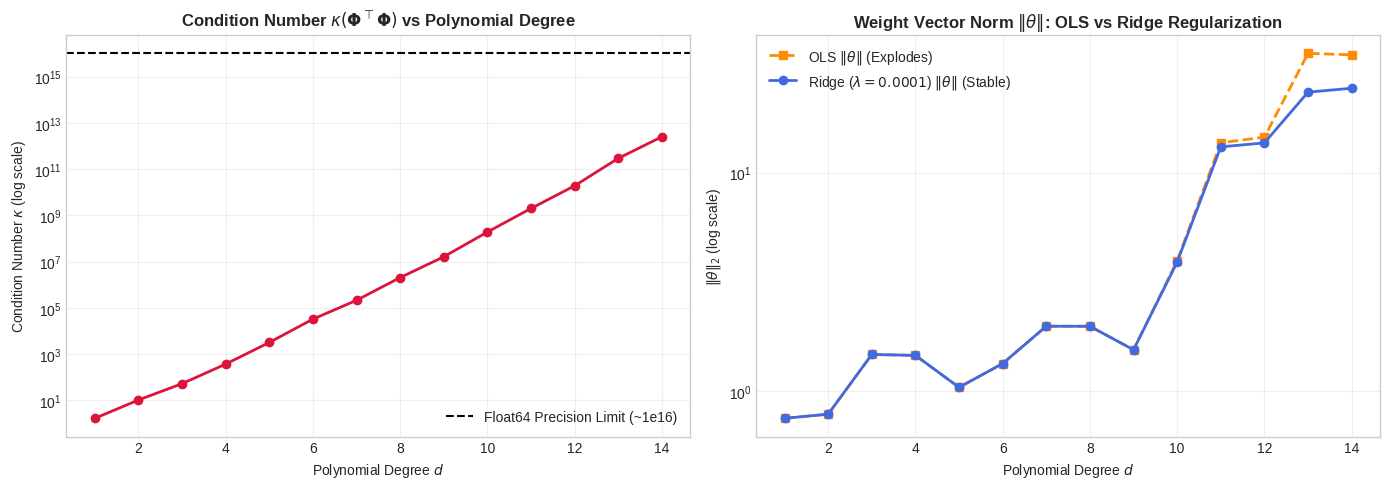

In [3]:
# Condition Number Analysis: Unregularized OLS vs Regularized Ridge Regression
poly_degrees = np.arange(1, 15)
cond_numbers = []
unreg_weights_norm = []
ridge_weights_norm = []
lambda_reg = 1e-4

for deg in poly_degrees:
    Phi_d = np.column_stack([x_obs**p for p in range(deg + 1)])
    A_d = Phi_d.T @ Phi_d
    cond = np.linalg.cond(A_d)
    cond_numbers.append(cond)
    
    try:
        theta_ols = np.linalg.solve(A_d, Phi_d.T @ y_obs)
        unreg_weights_norm.append(np.linalg.norm(theta_ols))
    except np.linalg.LinAlgError:
        unreg_weights_norm.append(np.nan)
        
    theta_ridge = np.linalg.solve(A_d + lambda_reg * np.eye(deg + 1), Phi_d.T @ y_obs)
    ridge_weights_norm.append(np.linalg.norm(theta_ridge))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(poly_degrees, cond_numbers, 'o-', color="crimson", lw=2)
ax1.axhline(1e16, color="black", ls="--", label="Float64 Precision Limit (~1e16)")
ax1.set_title(r"Condition Number $\kappa(\boldsymbol{\Phi}^\top \boldsymbol{\Phi})$ vs Polynomial Degree", fontsize=12, fontweight="bold")
ax1.set_xlabel("Polynomial Degree $d$")
ax1.set_ylabel(r"Condition Number $\kappa$ (log scale)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogy(poly_degrees, unreg_weights_norm, 's--', color="darkorange", lw=2, label=r"OLS $\|\theta\|$ (Explodes)")
ax2.semilogy(poly_degrees, ridge_weights_norm, 'o-', color="royalblue", lw=2, label=rf"Ridge ($\lambda={lambda_reg}$) $\|\theta\|$ (Stable)")
ax2.set_title(r"Weight Vector Norm $\|\theta\|$: OLS vs Ridge Regularization", fontsize=12, fontweight="bold")
ax2.set_xlabel("Polynomial Degree $d$")
ax2.set_ylabel(r"$\|\theta\|_2$ (log scale)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Exercise 9.2 — Maximum A Posteriori (MAP) Estimation, Ridge Regression & Effective Degrees of Freedom

### Problem Statement
In Section 9.2.2 of *Mathematics for Machine Learning*, when Maximum Likelihood suffers from overfitting or collinearity, a zero-mean isotropic Gaussian prior is placed on parameters:
$$p(\boldsymbol{\theta}) = \mathcal{N}(\boldsymbol{0}, \alpha^{-1} \boldsymbol{I}_K)$$
With observation likelihood $p(\boldsymbol{y} | \boldsymbol{\Phi}, \boldsymbol{\theta}) = \mathcal{N}(\boldsymbol{\Phi}\boldsymbol{\theta}, \sigma^2 \boldsymbol{I}_N)$, the MAP objective is:
$$\boldsymbol{\theta}_{\text{MAP}} = \arg\max_{\boldsymbol{\theta}} \left[ \ln p(\boldsymbol{y} | \boldsymbol{\Phi}, \boldsymbol{\theta}) + \ln p(\boldsymbol{\theta}) \right] = \arg\min_{\boldsymbol{\theta}} \left[ \frac{1}{2\sigma^2} \|\boldsymbol{y} - \boldsymbol{\Phi}\boldsymbol{\theta}\|^2 + \frac{\alpha}{2}\|\boldsymbol{\theta}\|^2 \right]$$

In this exercise:
1. **Derivation of Ridge MAP Solution:** Prove that setting the gradient to zero yields:
   $$\boldsymbol{\theta}_{\text{MAP}} = (\boldsymbol{\Phi}^\top \boldsymbol{\Phi} + \lambda \boldsymbol{I}_K)^{-1} \boldsymbol{\Phi}^\top \boldsymbol{y}, \quad \text{where } \lambda = \frac{\sigma^2}{\alpha}$$
2. **Singular Value Analysis & Shrinkage:** Using the SVD $\boldsymbol{\Phi} = \boldsymbol{U}\boldsymbol{\Sigma}\boldsymbol{V}^\top$, prove that Ridge regression shrinks the coordinates along each principal direction $i$ by a factor of $\frac{\sigma_i^2}{\sigma_i^2 + \lambda}$:
   $$\boldsymbol{\Phi} \boldsymbol{\theta}_{\text{MAP}} = \sum_{i=1}^K \frac{\sigma_i^2}{\sigma_i^2 + \lambda} (\boldsymbol{u}_i^\top \boldsymbol{y}) \boldsymbol{u}_i$$
3. **Effective Degrees of Freedom:** Define the effective degrees of freedom $\operatorname{df}(\lambda) = \operatorname{tr}(\boldsymbol{\Phi}(\boldsymbol{\Phi}^\top \boldsymbol{\Phi} + \lambda \boldsymbol{I})^{-1}\boldsymbol{\Phi}^\top) = \sum_{i=1}^K \frac{\sigma_i^2}{\sigma_i^2 + \lambda}$. Compute and plot the regularization path (parameter shrinkage) and effective degrees of freedom as $\lambda$ varies over $[10^{-4}, 10^3]$.


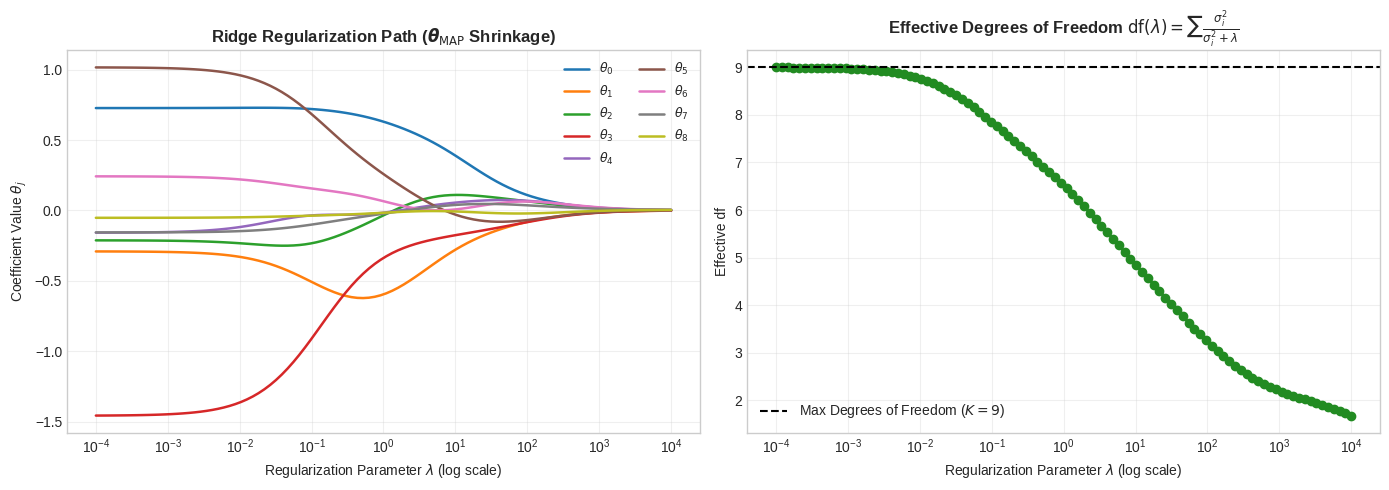

In [4]:
# Exercise 9.2: Ridge Regularization Path and Effective Degrees of Freedom
deg = 8
Phi_poly = np.column_stack([x_obs**p for p in range(deg + 1)])
U_svd, S_svd, Vt_svd = np.linalg.svd(Phi_poly, full_matrices=False)

lambda_grid = np.logspace(-4, 4, 100)
coef_paths = []
eff_df_list = []

for lam in lambda_grid:
    # Ridge solve
    theta_map = np.linalg.solve(Phi_poly.T @ Phi_poly + lam * np.eye(deg + 1), Phi_poly.T @ y_obs)
    coef_paths.append(theta_map)
    # Effective df: sum(s_i^2 / (s_i^2 + lambda))
    df = np.sum((S_svd**2) / (S_svd**2 + lam))
    eff_df_list.append(df)

coef_paths = np.array(coef_paths)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ridge Trace
for p in range(deg + 1):
    ax1.plot(lambda_grid, coef_paths[:, p], lw=1.8, label=rf"$\theta_{{{p}}}$")
ax1.set_xscale('log')
ax1.set_title(r"Ridge Regularization Path ($\boldsymbol{\theta}_{\mathrm{MAP}}$ Shrinkage)", fontsize=12, fontweight="bold")
ax1.set_xlabel(r"Regularization Parameter $\lambda$ (log scale)")
ax1.set_ylabel(r"Coefficient Value $\theta_j$")
ax1.legend(loc="upper right", ncol=2, fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Effective Degrees of Freedom
ax2.plot(lambda_grid, eff_df_list, 'o-', color="forestgreen", lw=2)
ax2.axhline(deg + 1, color="black", ls="--", label=f"Max Degrees of Freedom ($K = {deg + 1}$)")
ax2.set_xscale('log')
ax2.set_title(r"Effective Degrees of Freedom $\mathrm{df}(\lambda) = \sum \frac{\sigma_i^2}{\sigma_i^2 + \lambda}$", fontsize=12, fontweight="bold")
ax2.set_xlabel(r"Regularization Parameter $\lambda$ (log scale)")
ax2.set_ylabel(r"Effective df")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Exercise 9.3 — Bayesian Linear Regression & Sequential Posterior Updating

### Problem Statement
In Section 9.3 of *Mathematics for Machine Learning*, Bayesian linear regression provides a principled probabilistic approach by maintaining a full probability distribution over parameter space $\boldsymbol{\theta}$.

Given:
- Prior distribution: $p(\boldsymbol{\theta}) = \mathcal{N}(\boldsymbol{m}_0, \boldsymbol{S}_0)$ with $\boldsymbol{m}_0 = \boldsymbol{0}$, $\boldsymbol{S}_0 = \alpha^{-1} \boldsymbol{I}_K$.
- Observation likelihood: $p(\boldsymbol{y} | \boldsymbol{\Phi}, \boldsymbol{\theta}) = \mathcal{N}(\boldsymbol{\Phi}\boldsymbol{\theta}, \sigma^2 \boldsymbol{I}_N)$ with precision $\beta = \sigma^{-2}$.

In this exercise:
1. **Conjugate Posterior Derivation:** Derive the Gaussian conjugate posterior $p(\boldsymbol{\theta} | \boldsymbol{y}) = \mathcal{N}(\boldsymbol{m}_N, \boldsymbol{S}_N)$:
   $$\boldsymbol{S}_N = \left(\boldsymbol{S}_0^{-1} + \beta \boldsymbol{\Phi}^\top \boldsymbol{\Phi}\right)^{-1}, \quad \boldsymbol{m}_N = \boldsymbol{S}_N \left(\boldsymbol{S}_0^{-1}\boldsymbol{m}_0 + \beta \boldsymbol{\Phi}^\top \boldsymbol{y}\right)$$
2. **Predictive Distribution:** For any test input $\boldsymbol{x}_*$, derive the marginal posterior predictive distribution:
   $$p(y_* | \boldsymbol{x}_*, \mathcal{D}) = \mathcal{N}\left(\boldsymbol{\phi}(\boldsymbol{x}_*)^\top \boldsymbol{m}_N, \, \sigma^2 + \boldsymbol{\phi}(\boldsymbol{x}_*)^\top \boldsymbol{S}_N \boldsymbol{\phi}(\boldsymbol{x}_*)\right)$$
3. **Sequential Updating with Multiprocessing:** Implement sequential Bayesian updating as data points arrive incrementally ($N \in \{0, 1, 2, 20\}$) using `bayesian_predictive_worker`.


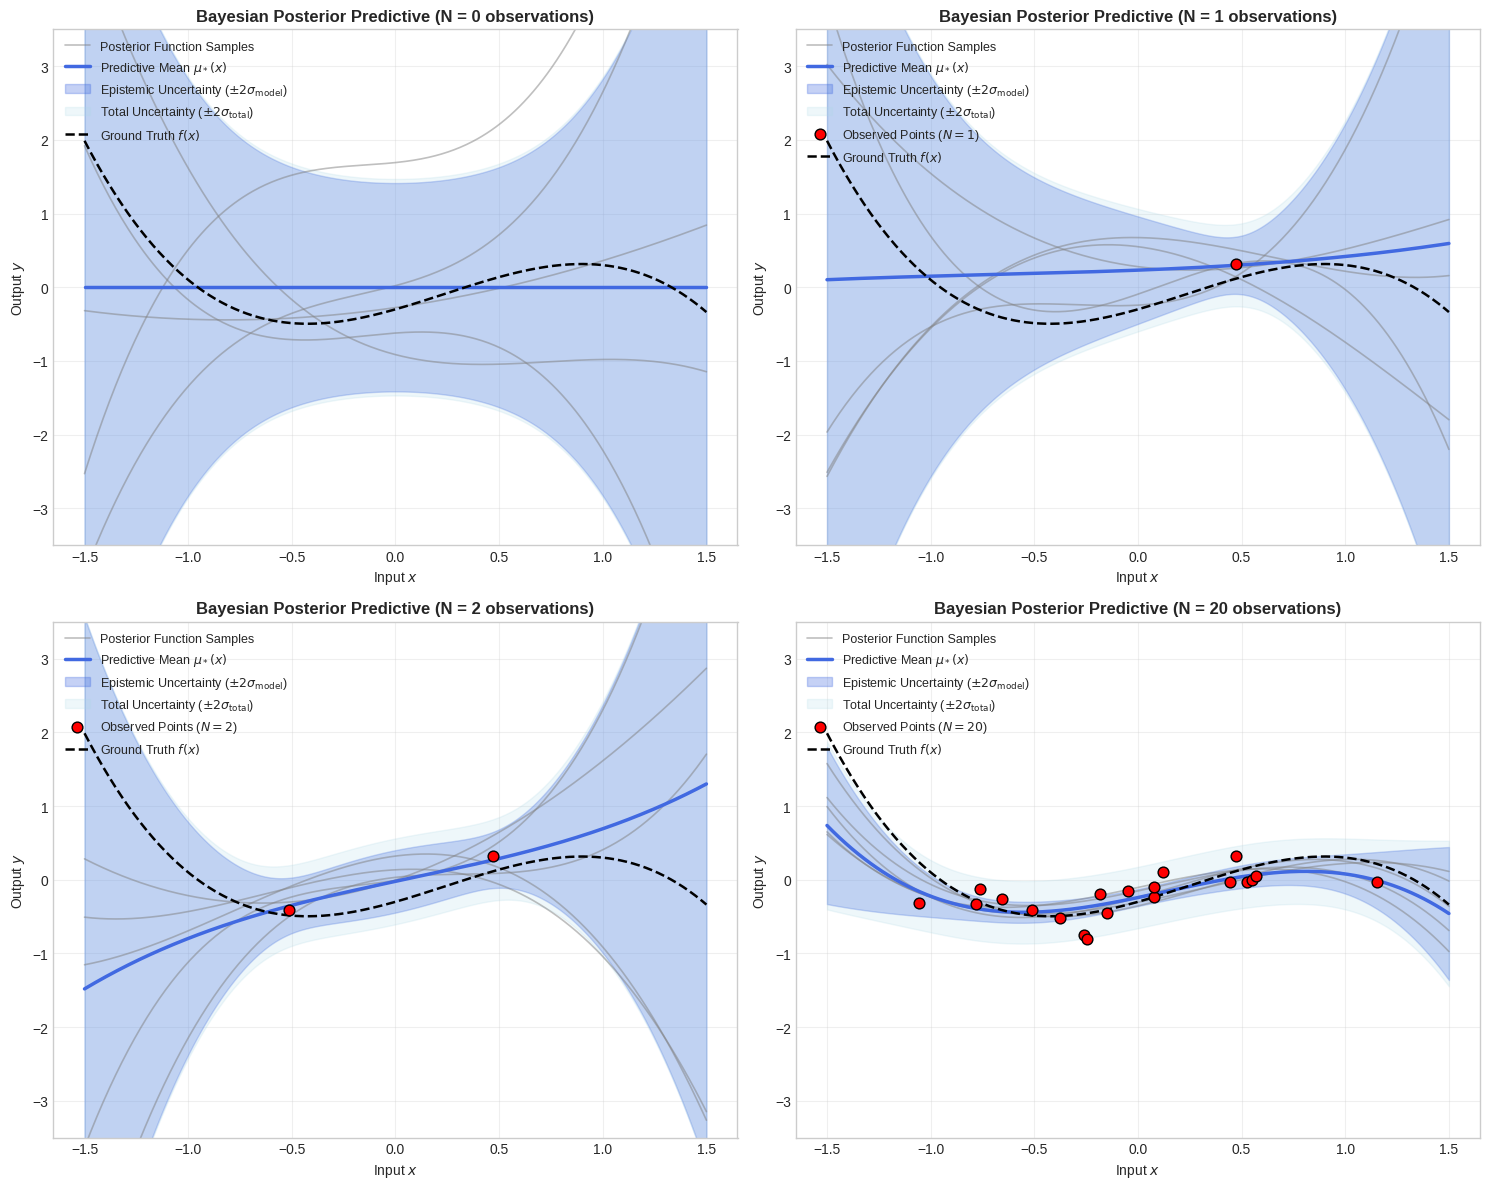

In [5]:
# Exercise 9.3: Sequential Bayesian Linear Regression with Parallel Predictive Worker
alpha_prior = 2.0
sigma_noise = 0.2
beta_noise = 1.0 / (sigma_noise**2)
poly_degree = 3
K_dim = poly_degree + 1

def true_func(x):
    return -0.3 + 0.8 * x + 0.5 * x**2 - 0.7 * x**3

np.random.seed(123)
x_all = np.random.uniform(-1.2, 1.2, size=20)
y_all = true_func(x_all) + np.random.normal(0, sigma_noise, size=20)

x_grid = np.linspace(-1.5, 1.5, 400)
sample_counts = [0, 1, 2, 20]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

chunk_size = len(x_grid) // cpu_cores or 1
x_chunks = [x_grid[i:i + chunk_size] for i in range(0, len(x_grid), chunk_size)]

for idx, N_sub in enumerate(sample_counts):
    ax = axes[idx]
    if N_sub == 0:
        m_N = np.zeros(K_dim)
        S_N = (1.0 / alpha_prior) * np.eye(K_dim)
    else:
        x_sub = x_all[:N_sub]
        y_sub = y_all[:N_sub]
        Phi_sub = np.column_stack([x_sub**p for p in range(K_dim)])
        S_N_inv = alpha_prior * np.eye(K_dim) + beta_noise * (Phi_sub.T @ Phi_sub)
        S_N = np.linalg.inv(S_N_inv)
        m_N = beta_noise * (S_N @ (Phi_sub.T @ y_sub))
        
    tasks = [(chunk, m_N, S_N, sigma_noise**2, poly_degree) for chunk in x_chunks]
    with ThreadPoolExecutor() as executor:
        worker_res = list(executor.map(bayesian_predictive_worker, tasks))
        
    pred_mean = np.concatenate([r[0] for r in worker_res])
    epistemic_std = np.concatenate([r[1] for r in worker_res])
    total_std = np.concatenate([r[2] for r in worker_res])
    
    theta_samples = np.random.multivariate_normal(m_N, S_N, size=5)
    Phi_grid = np.column_stack([x_grid**p for p in range(K_dim)])
    
    for s_idx, theta_s in enumerate(theta_samples):
        ax.plot(x_grid, Phi_grid @ theta_s, color="gray", alpha=0.5, lw=1.2, 
                label="Posterior Function Samples" if s_idx == 0 else "")
        
    ax.plot(x_grid, pred_mean, color="royalblue", lw=2.5, label=r"Predictive Mean $\mu_*(x)$")
    ax.fill_between(x_grid, pred_mean - 2 * epistemic_std, pred_mean + 2 * epistemic_std, 
                    color="royalblue", alpha=0.3, label=r"Epistemic Uncertainty ($\pm 2\sigma_{\mathrm{model}}$)")
    ax.fill_between(x_grid, pred_mean - 2 * total_std, pred_mean + 2 * total_std, 
                    color="lightblue", alpha=0.2, label=r"Total Uncertainty ($\pm 2\sigma_{\mathrm{total}}$)")
    
    if N_sub > 0:
        ax.scatter(x_all[:N_sub], y_all[:N_sub], color="red", s=60, zorder=5, edgecolors="black", label=f"Observed Points ($N={N_sub}$)")
        
    ax.plot(x_grid, true_func(x_grid), 'k--', lw=1.8, label="Ground Truth $f(x)$")
    ax.set_title(f"Bayesian Posterior Predictive (N = {N_sub} observations)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Input $x$")
    ax.set_ylabel("Output $y$")
    ax.set_ylim(-3.5, 3.5)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Exercise 9.4 — Model Evaluation: Overfitting, Generalization & 5-Fold Cross-Validation

### Problem Statement
In the official MML companion tutorial on Linear Regression, evaluating the quality of regression models requires assessing generalization performance on unseen test data:
$$\operatorname{RMSE} = \sqrt{\frac{1}{N_{\text{test}}} \sum_{n=1}^{N_{\text{test}}} (y_n - \hat{y}_n)^2}$$

In this exercise:
1. Generate a noisy dataset partitioned into 70% training and 30% held-out test sets.
2. Fit unregularized polynomial models of degrees $d \in \{1, \dots, 10\}$.
3. Track training RMSE vs. test RMSE, illustrating the onset of severe overfitting as degree increases.
4. Perform 5-fold cross-validation on the training set to choose the optimal polynomial order.


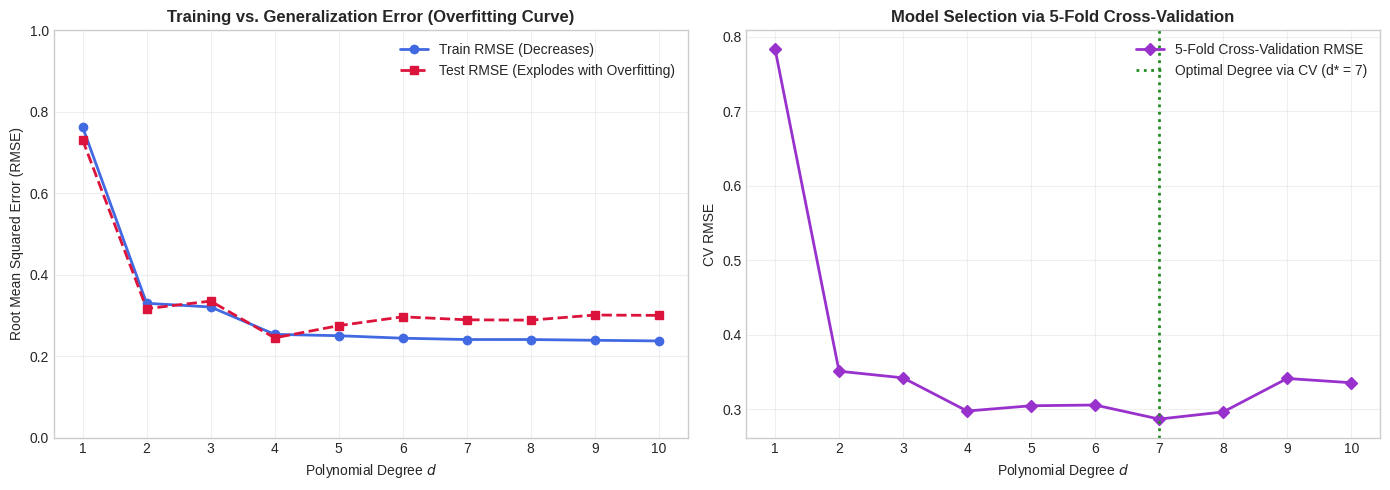

Optimal Model Selected via Cross-Validation: Degree 7


In [6]:
# Exercise 9.4: Evaluating Model Quality via Train/Test RMSE and 5-Fold Cross-Validation
np.random.seed(99)
N_total = 60
x_all_eval = np.sort(np.random.uniform(-1.0, 1.0, N_total))
y_all_eval = np.cos(np.pi * x_all_eval) + 0.25 * np.random.randn(N_total)

# 70/30 Train/Test split
n_train = int(0.7 * N_total)
perm = np.random.permutation(N_total)
train_idx, test_idx = perm[:n_train], perm[n_train:]

x_tr, y_tr = x_all_eval[train_idx], y_all_eval[train_idx]
x_te, y_te = x_all_eval[test_idx], y_all_eval[test_idx]

degrees_eval = np.arange(1, 11)
train_rmse_list = []
test_rmse_list = []
cv_rmse_list = []

# 5-fold CV splits on training data
K_folds = 5
cv_splits = np.array_split(np.random.permutation(n_train), K_folds)

for d in degrees_eval:
    # Train / Test fit
    c = np.polyfit(x_tr, y_tr, deg=d)
    pred_tr = np.polyval(c, x_tr)
    pred_te = np.polyval(c, x_te)
    
    train_rmse_list.append(np.sqrt(np.mean((y_tr - pred_tr)**2)))
    test_rmse_list.append(np.sqrt(np.mean((y_te - pred_te)**2)))
    
    # 5-Fold CV on training set
    fold_mses = []
    for f in range(K_folds):
        val_fold_idx = cv_splits[f]
        tr_fold_idx = np.setdiff1d(np.arange(n_train), val_fold_idx)
        c_f = np.polyfit(x_tr[tr_fold_idx], y_tr[tr_fold_idx], deg=d)
        pred_f = np.polyval(c_f, x_tr[val_fold_idx])
        fold_mses.append(np.mean((y_tr[val_fold_idx] - pred_f)**2))
    cv_rmse_list.append(np.sqrt(np.mean(fold_mses)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Test RMSE
ax1.plot(degrees_eval, train_rmse_list, 'o-', color="royalblue", lw=2, label="Train RMSE (Decreases)")
ax1.plot(degrees_eval, test_rmse_list, 's--', color="crimson", lw=2, label="Test RMSE (Explodes with Overfitting)")
ax1.set_title("Training vs. Generalization Error (Overfitting Curve)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Polynomial Degree $d$")
ax1.set_ylabel("Root Mean Squared Error (RMSE)")
ax1.set_xticks(degrees_eval)
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: 5-Fold CV Error on Training Set
ax2.plot(degrees_eval, cv_rmse_list, 'D-', color="darkorchid", lw=2, label="5-Fold Cross-Validation RMSE")
opt_d_cv = degrees_eval[np.argmin(cv_rmse_list)]
ax2.axvline(opt_d_cv, color="forestgreen", ls=":", lw=2, label=f"Optimal Degree via CV (d* = {opt_d_cv})")
ax2.set_title("Model Selection via 5-Fold Cross-Validation", fontsize=12, fontweight="bold")
ax2.set_xlabel("Polynomial Degree $d$")
ax2.set_ylabel("CV RMSE")
ax2.set_xticks(degrees_eval)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal Model Selected via Cross-Validation: Degree {opt_d_cv}")


---
### Key Takeaways from Chapter 9
1. **Geometric Projection:** Maximum likelihood linear regression is mathematically equivalent to the orthogonal projection of target vector $\boldsymbol{y} \in \mathbb{R}^N$ onto the column space of design matrix $\boldsymbol{\Phi}$. The projection matrix $\boldsymbol{P} = \boldsymbol{\Phi}(\boldsymbol{\Phi}^\top \boldsymbol{\Phi})^{-1}\boldsymbol{\Phi}^\top$ is symmetric and idempotent, guaranteeing residuals are orthogonal to feature subspace.
2. **MAP and Ridge Shrinkage:** Adding a Gaussian prior is equivalent to $L_2$ Ridge regularization. In SVD coordinates, Ridge shrinks components proportional to $\frac{\sigma_i^2}{\sigma_i^2 + \lambda}$, effectively reducing the degrees of freedom $\operatorname{df}(\lambda)$ and stabilizing matrix inversion.
3. **Bayesian Uncertainty Decomposition:** Bayesian linear regression maintains a posterior distribution over parameters $\boldsymbol{\theta} \sim \mathcal{N}(\boldsymbol{m}_N, \boldsymbol{S}_N)$. Predictive variance decomposes cleanly into irreducible measurement noise (aleatoric) and parameter uncertainty (epistemic), which contracts in regions with dense observations.
4. **Generalization and Validation:** Training RMSE monotonically decreases with polynomial degree, while test RMSE explodes due to Runge's phenomenon and overfitting. $K$-fold cross-validation reliably identifies the optimal hypothesis complexity without data leakage.
